# Figure 1: Metabolic Rate Distribution by Vessel and Time of Day ('Environment')

This notebook isolates the code needed to reproduce the Figure 1 box-and-whisker chart


The data file required is batch_summary.csv which is produced in the notebook A_batch_respirometry_final.ipynb

## Load in batch_summary.csv and style code

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them. These trials
# yielded negative respiration rates and are not included in the main analysis, but they are included 
# here for completeness. During those trials, our seawater filter clogged and we used unfiltered seawater, 
# which likely introduced contaminants that affected the calculation of respiration rates.

use_unfiltered = False

# Locate the processed batch summary from common notebook working directories.
candidate_paths = [
    Path.cwd() / "../data/processed/batch_summary.csv",
    Path.cwd() / "data/processed/batch_summary.csv",
    Path("/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv"),
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/processed/batch_summary.csv")

agg_df = pd.read_csv(data_path)
print(f"Loaded {len(agg_df)} rows from {data_path}")

Loaded 71 rows from /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv


In [11]:
# Load shared Figure style + palette
from pathlib import Path
import importlib.util

style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

LIGHT_BLUE = palette['light_blue']
DARK_BLUE = palette['dark_blue']
LIGHT_ORANGE = palette['light_orange']
DARK_ORANGE = palette['dark_orange']

print(f'Shared style loaded from: {style_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle


## Statistics associated with the figure

In [12]:
# Linear-model contrasts focused on cylinder-night vs all other groups
# Hypothesis of interest: cylinder-night is higher than each other vessel/time combination.

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.multitest import multipletests
except ImportError:
    print("statsmodels is required for this cell. Install with: pip install statsmodels")
else:
    # Reuse plot_df if it exists; otherwise recreate from agg_df.
    if 'plot_df' in locals() and not plot_df.empty:
        stats_input = plot_df.copy()
    elif 'agg_df' in locals() and not agg_df.empty:
        stats_input = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()
    else:
        stats_input = pd.DataFrame()

    if stats_input.empty:
        print("No data available for statistics.")
    else:
        required_cols = {'vessel', 'environment', 'RMR'}
        missing = required_cols - set(stats_input.columns)
        if missing:
            print(f"Missing required columns for modeling: {sorted(missing)}")
        else:
            dat = stats_input.dropna(subset=['vessel', 'environment', 'RMR']).copy()
            dat['group_label'] = dat['vessel'].astype(str) + '_' + dat['environment'].astype(str)

            reference_group = 'cylinder_night'
            if reference_group not in set(dat['group_label']):
                print(f"Reference group '{reference_group}' not found. Available groups: {sorted(dat['group_label'].unique())}")
            else:
                # OLS with cylinder_night as reference and heteroskedasticity-robust SE.
                model = smf.ols(
                    "RMR ~ C(group_label, Treatment(reference='cylinder_night'))",
                    data=dat,
                ).fit(cov_type='HC3')

                group_means = dat.groupby('group_label')['RMR'].mean()
                group_ns = dat.groupby('group_label')['RMR'].size()
                ref_mean = group_means[reference_group]

                rows = []
                tested_terms = []
                tested_pvals_one_sided = []

                for group in sorted(group_means.index):
                    if group == reference_group:
                        continue

                    term = f"C(group_label, Treatment(reference='cylinder_night'))[T.{group}]"
                    if term not in model.params.index:
                        continue

                    # Coefficient is (group - cylinder_night).
                    coef_group_minus_ref = model.params[term]
                    p_two_sided = float(model.pvalues[term])

                    # One-sided p for H1: cylinder_night > group  <=>  (group - cylinder_night) < 0.
                    if coef_group_minus_ref < 0:
                        p_one_sided = p_two_sided / 2.0
                    else:
                        p_one_sided = 1.0 - (p_two_sided / 2.0)

                    tested_terms.append(group)
                    tested_pvals_one_sided.append(p_one_sided)

                    rows.append({
                        'comparison': f"cylinder_night vs {group}",
                        'n_cylinder_night': int(group_ns[reference_group]),
                        'n_group': int(group_ns[group]),
                        'mean_cylinder_night': float(ref_mean),
                        'mean_group': float(group_means[group]),
                        'diff_cylinder_minus_group': float(-coef_group_minus_ref),
                        'p_two_sided': p_two_sided,
                        'p_one_sided_cyl_gt_group': p_one_sided,
                    })

                if not rows:
                    print("No non-reference groups found for comparison.")
                else:
                    # Holm correction on one-sided p-values for the family of cylinder-night contrasts.
                    reject, p_holm, _, _ = multipletests(tested_pvals_one_sided, alpha=0.05, method='holm')

                    for i, row in enumerate(rows):
                        row['p_one_sided_holm'] = float(p_holm[i])
                        row['significant_holm_0.05'] = bool(reject[i])

                    contrast_df = pd.DataFrame(rows).sort_values('comparison').reset_index(drop=True)

                    print("Model: OLS with HC3 robust SE")
                    print("Formula: RMR ~ C(group_label), reference = cylinder_night")
                    print("Hypothesis test direction: cylinder_night > comparison group")
                    display(contrast_df)

                    print("\nCaption-ready statistics sentence:")
                    sig_count = int(contrast_df['significant_holm_0.05'].sum())
                    total_count = len(contrast_df)
                    print(
                        f"Cylinder-night metabolic rate was significantly higher than {sig_count} of {total_count} "
                        f"other vessel/time groups (one-sided contrasts from OLS with HC3 SE, Holm-corrected)."
                    )

Model: OLS with HC3 robust SE
Formula: RMR ~ C(group_label), reference = cylinder_night
Hypothesis test direction: cylinder_night > comparison group


,comparison,n_cylinder_night,n_group,mean_cylinder_night,mean_group,diff_cylinder_minus_group,p_two_sided,p_one_sided_cyl_gt_group,p_one_sided_holm,significant_holm_0.05
0,cylinder_night vs medium_night,8,6,5.844194,3.614779,2.229415,3.006731e-02,1.503366e-02,1.503366e-02,True
1,cylinder_night vs small_day,8,18,5.844194,1.181223,4.662971,6.524617e-07,3.262308e-07,9.786925e-07,True
2,cylinder_night vs small_night,8,26,5.844194,2.097811,3.746383,7.633049e-05,3.816524e-05,7.633049e-05,True



Caption-ready statistics sentence:
Cylinder-night metabolic rate was significantly higher than 3 of 3 other vessel/time groups (one-sided contrasts from OLS with HC3 SE, Holm-corrected).


## Create the figure in addition to summary statistics


Summary statistics by group:


count      mean       std       min       max
vessel   environment                                               
cylinder night            8  5.844194  2.439238  2.897411  8.546660
medium   night            6  3.614779  1.015635  2.521120  5.398751
small    day             18  1.181223  0.696188  0.375336  2.995435
         night           26  2.097811  1.084139  0.384284  4.356231

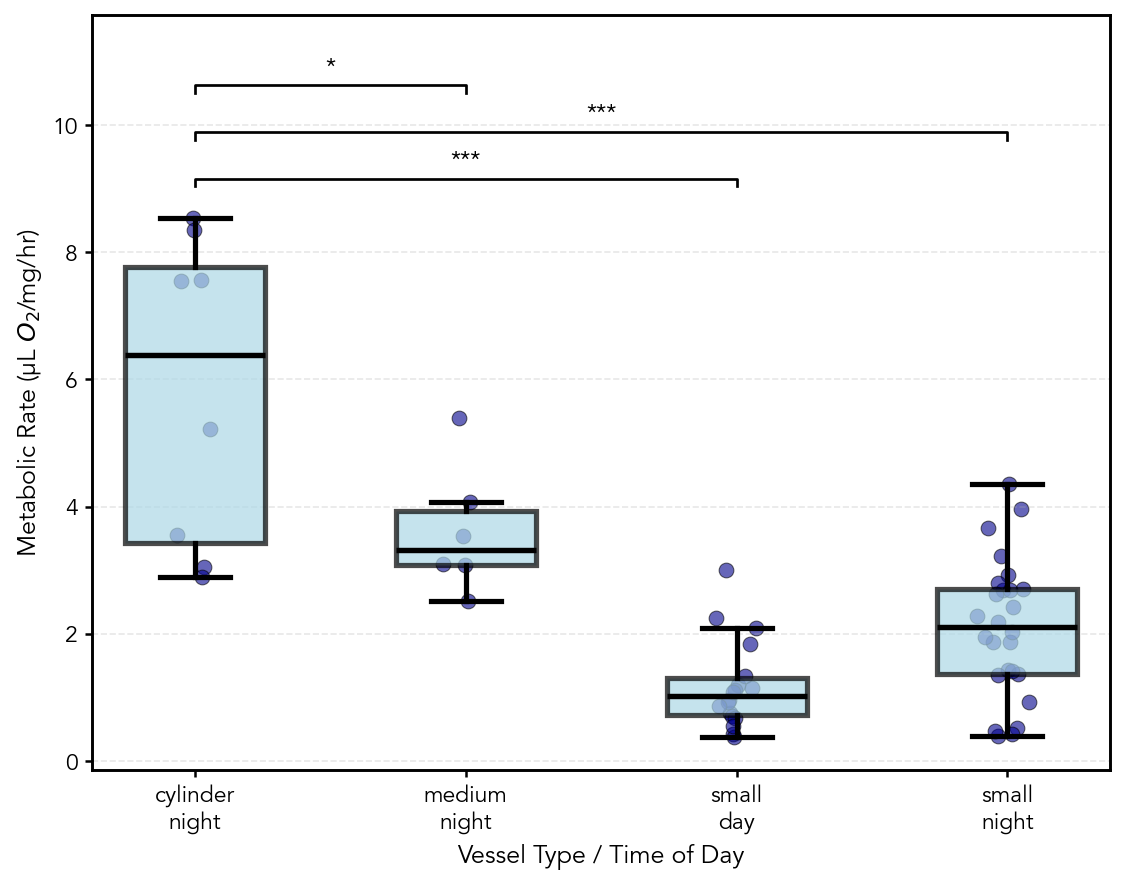

In [13]:
if 'agg_df' in locals() and not agg_df.empty:
    # Apply filtering based on toggle.
    plot_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

    # Group by vessel and environment if those columns exist.
    group_cols = [col for col in ['vessel', 'environment'] if col in plot_df.columns]

    if group_cols:
        stats = plot_df.groupby(group_cols)['RMR'].agg(['count', 'mean', 'std', 'min', 'max'])
        print("\nSummary statistics by group:")
        display(stats)

        plot_df['group'] = plot_df['vessel'] + '\n' + plot_df['environment']
        groups = sorted(plot_df['group'].unique())
        data_by_group = [plot_df[plot_df['group'] == g]['RMR'].values for g in groups]

        # Keep boxes narrow but place category centers closer together.
        positions = np.arange(len(groups)) * 0.58

        # Make canvas width proportional to number of groups so whitespace stays compact.
        fig_width = max(6.5, 1.55 * len(groups) + 1.4)
        fig, ax = plt.subplots(figsize=(fig_width, 6))

        bp = ax.boxplot(
            data_by_group,
            positions=positions,
            tick_labels=groups,
            patch_artist=True,
            widths=0.30,
            showfliers=False,
            boxprops=dict(linewidth=2.5, color='black'),
            whiskerprops=dict(linewidth=2.5, color='black'),
            capprops=dict(linewidth=2.5, color='black'),
            medianprops=dict(linewidth=2.6, color='black'),
        )
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)

        for i, group in enumerate(groups):
            y_data = plot_df[plot_df['group'] == group]['RMR'].values
            x_data = np.random.normal(positions[i], 0.03, size=len(y_data))
            ax.scatter(
                x_data,
                y_data,
                alpha=0.6,
                s=50,
                c='darkblue',
                edgecolors='black',
                linewidth=0.5,
            )

        # Add significance brackets from cylinder-night to each other group if model contrasts are available.
        if 'contrast_df' in locals() and not contrast_df.empty:
            x_lookup = {g: positions[i] for i, g in enumerate(groups)}
            ref_label = 'cylinder\nnight'

            if ref_label in x_lookup:
                ref_x = x_lookup[ref_label]
                y_min = float(np.nanmin(plot_df['RMR'].values))
                y_max = float(np.nanmax(plot_df['RMR'].values))
                y_range = y_max - y_min
                if y_range <= 0:
                    y_range = max(abs(y_max), 1.0)

                bracket_base = y_max + 0.06 * y_range
                bracket_step = 0.09 * y_range
                bracket_tick = 0.015 * y_range

                # Plot in ascending adjusted p-value order.
                sig_rows = contrast_df.sort_values('p_one_sided_holm').reset_index(drop=True)

                used = 0
                for idx, row in sig_rows.iterrows():
                    group_label = row['comparison'].split(' vs ')[1]
                    comp_label = group_label.replace('_', '\n', 1)
                    if comp_label not in x_lookup:
                        continue

                    comp_x = x_lookup[comp_label]
                    y = bracket_base + used * bracket_step

                    ax.plot(
                        [ref_x, ref_x, comp_x, comp_x],
                        [y, y + bracket_tick, y + bracket_tick, y],
                        color='black',
                        linewidth=1.3,
                    )

                    p_adj = float(row['p_one_sided_holm'])
                    if p_adj < 0.001:
                        stars = '***'
                    elif p_adj < 0.01:
                        stars = '**'
                    elif p_adj < 0.05:
                        stars = '*'
                    else:
                        stars = 'ns'

                    ax.text(
                        (ref_x + comp_x) / 2,
                        y + bracket_tick + 0.01 * y_range,
                        stars,
                        ha='center',
                        va='bottom',
                        fontsize=11,
                        fontweight='bold',
                    )
                    used += 1

                if used > 0:
                    ax.set_ylim(top=bracket_base + used * bracket_step + 0.06 * y_range)

        ax.set_xticks(positions)
        ax.set_xticklabels(groups)
        ax.set_ylabel('Metabolic Rate (µL $O_2$/mg/hr)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Vessel Type / Time of Day', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Tighten side whitespace around first and last categories.
        ax.set_xlim(positions[0] - 0.22, positions[-1] + 0.22)

        plt.xticks(rotation=0, ha='center')
        plt.tight_layout()
        plt.show()
    else:
        print("\nOverall statistics:")
        print(plot_df['RMR'].describe())
else:
    print('No data available for statistics.')

In [14]:
# Save Figure 1 to files
from pathlib import Path

figures_dir = Path.cwd() / "../figures"
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    png_path = (figures_dir / 'Figure1_BarChart.png').resolve()
    pdf_path = (figures_dir / 'Figure1_BarChart.pdf').resolve()

    fig.savefig(png_path, dpi=600, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")
else:
    print("No figure object found. Run the plotting cell first.")

Saved PNG: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure1_BarChart.png
Saved PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure1_BarChart.pdf
